In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from loguru import logger
from skactiveml.classifier import SklearnClassifier
from skactiveml.pool import QueryByCommittee, RandomSampling, UncertaintySampling
from skactiveml.utils import MISSING_LABEL
from sklearn.datasets import load_digits, load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Load datasets

In [3]:
iris = load_iris()
digits = load_digits()

In [4]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

# Evaluate

In [6]:
def evaluate(_datasets):
    for dataset_name, (X, y_true) in _datasets.items():
        logger.info(f"Evaluating dataset: {dataset_name}")
        clf = SklearnClassifier(RandomForestClassifier(), classes=np.unique(y_true))
        methods = ["margin_sampling", "entropy", "least_confident", "random_sampling", "KL_divergence"]
        n_cycles = 100
        accuracies = {method: [] for method in methods}
        f1_scores = {method: [] for method in methods}
        for method in methods:
            if method in ["random_sampling"]:
                qs = RandomSampling(random_state=42)
            elif method in ["KL_divergence"]:
                qs = QueryByCommittee(random_state=42, method=method)
            else:
                qs = UncertaintySampling(method=method, random_state=42)
            y = np.full(shape=y_true.shape, fill_value=MISSING_LABEL)
            clf.fit(X, y)
            for c in range(n_cycles):
                if method in ["random_sampling"]:
                    query_idx = qs.query(X=X, y=y, batch_size=1)
                elif method in ["KL_divergence"]:
                    query_idx = qs.query(X=X, y=y, ensemble=clf, batch_size=1)
                else:
                    query_idx = qs.query(X=X, y=y, clf=clf, batch_size=1)
                y[query_idx] = y_true[query_idx]
                clf.fit(X, y)
                accuracy = clf.score(X, y_true)
                accuracies[method].append(accuracy)
                f1 = f1_score(y_true, clf.predict(X), average="weighted")
                f1_scores[method].append(f1)

        # Print accuracies for each method
        logger.info(f"Accuracies for dataset: {dataset_name}")
        for method, accuracy in accuracies.items():
            logger.info(f"\tMethod: {method}, Accuracy: {accuracy[-1]:.4f}")
        for method, f1 in f1_scores.items():
            logger.info(f"\tMethod: {method}, F1: {f1[-1]:.4f}")

        # Plot accuracies
        plt.figure(figsize=(10, 6))
        max_accuracy = 0
        best_method = ""
        for method, accuracy in accuracies.items():
            plt.plot(range(1, n_cycles + 1), accuracy, label=method, marker="o")
            max_accuracy = max(max_accuracy, accuracy[-1])

        max_f1 = 0
        # Plot f1 scores
        for method, f1 in f1_scores.items():
            plt.plot(range(1, n_cycles + 1), f1, label=f"{method} (F1)", linestyle="--")
            if f1[-1] > max_f1:
                max_f1 = f1[-1]
                best_method = method

        plt.title(f"Accuracy vs Iterations - {dataset_name}")
        plt.xlabel("Iterations")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

        # Print the method with the highest accuracy
        logger.info(
            f"The method with the highest accuracy for dataset {dataset_name} is {best_method} with an accuracy of {max_accuracy:.4f}.\n",
        )

2026-05-12 01:04:44.509 | INFO     | __main__:evaluate:3 - Evaluating dataset: Iris
2026-05-12 01:05:34.366 | INFO     | __main__:evaluate:39 - Accuracies for dataset: Iris
2026-05-12 01:05:34.366 | INFO     | __main__:evaluate:41 - 	Method: margin_sampling, Accuracy: 1.0000
2026-05-12 01:05:34.367 | INFO     | __main__:evaluate:41 - 	Method: entropy, Accuracy: 1.0000
2026-05-12 01:05:34.367 | INFO     | __main__:evaluate:41 - 	Method: least_confident, Accuracy: 1.0000
2026-05-12 01:05:34.367 | INFO     | __main__:evaluate:41 - 	Method: random_sampling, Accuracy: 0.9733
2026-05-12 01:05:34.367 | INFO     | __main__:evaluate:41 - 	Method: KL_divergence, Accuracy: 1.0000
2026-05-12 01:05:34.368 | INFO     | __main__:evaluate:43 - 	Method: margin_sampling, F1: 1.0000
2026-05-12 01:05:34.368 | INFO     | __main__:evaluate:43 - 	Method: entropy, F1: 1.0000
2026-05-12 01:05:34.368 | INFO     | __main__:evaluate:43 - 	Method: least_confident, F1: 1.0000
2026-05-12 01:05:34.368 | INFO     | __

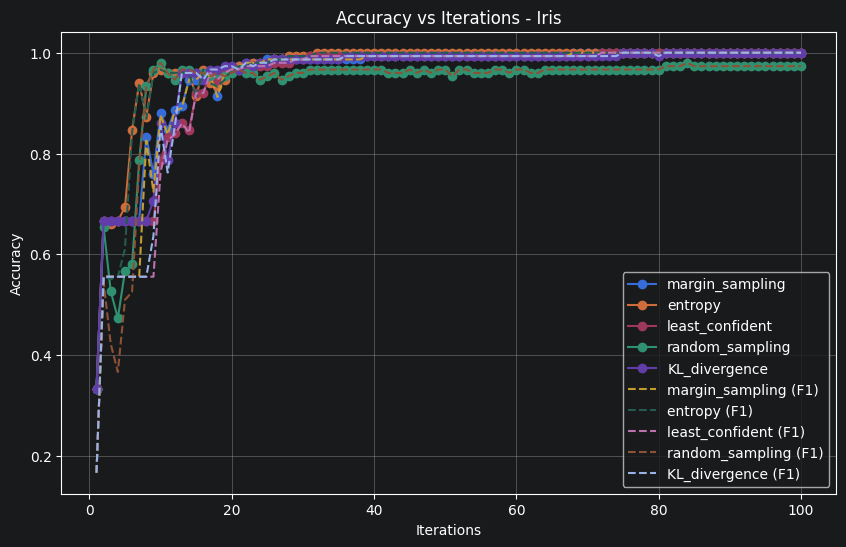

2026-05-12 01:05:34.489 | INFO     | __main__:evaluate:70 - The method with the highest accuracy for dataset Iris is margin_sampling with an accuracy of 1.0000.

2026-05-12 01:05:34.491 | INFO     | __main__:evaluate:3 - Evaluating dataset: Digits
2026-05-12 01:06:39.382 | INFO     | __main__:evaluate:39 - Accuracies for dataset: Digits
2026-05-12 01:06:39.382 | INFO     | __main__:evaluate:41 - 	Method: margin_sampling, Accuracy: 0.9572
2026-05-12 01:06:39.383 | INFO     | __main__:evaluate:41 - 	Method: entropy, Accuracy: 0.8753
2026-05-12 01:06:39.383 | INFO     | __main__:evaluate:41 - 	Method: least_confident, Accuracy: 0.9188
2026-05-12 01:06:39.383 | INFO     | __main__:evaluate:41 - 	Method: random_sampling, Accuracy: 0.8531
2026-05-12 01:06:39.383 | INFO     | __main__:evaluate:41 - 	Method: KL_divergence, Accuracy: 0.8820
2026-05-12 01:06:39.383 | INFO     | __main__:evaluate:43 - 	Method: margin_sampling, F1: 0.9571
2026-05-12 01:06:39.383 | INFO     | __main__:evaluate:43 -

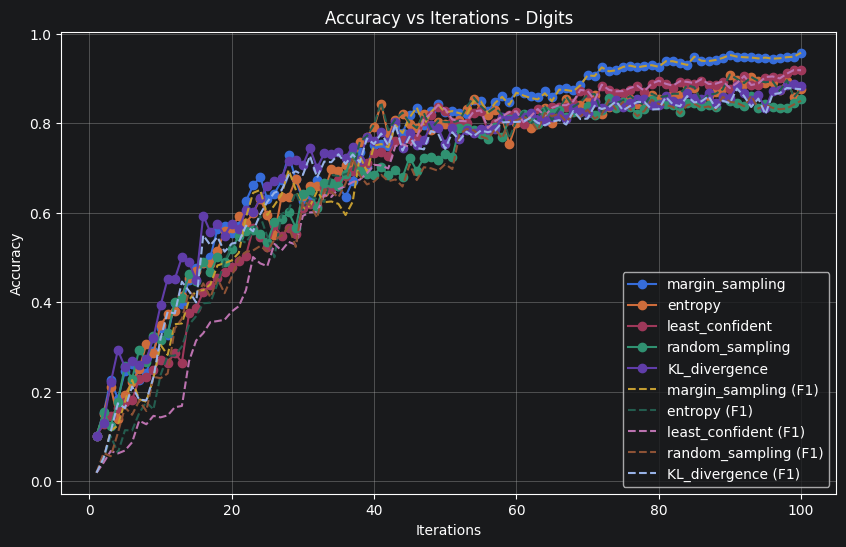

2026-05-12 01:06:39.477 | INFO     | __main__:evaluate:70 - The method with the highest accuracy for dataset Digits is margin_sampling with an accuracy of 0.9572.



In [7]:
evaluate({"Iris": (iris.data, iris.target), "Digits": (digits.data, digits.target)})